In [1]:
# Import the necessary libraries for the programme

from pathlib import Path

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor

In [39]:
FILE_PATH = Path.cwd().parent / "datasets" / "test_energy_data.csv"

In [40]:
df = pd.read_csv(FILE_PATH)

In [41]:
df.head(3)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83


In [42]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [44]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


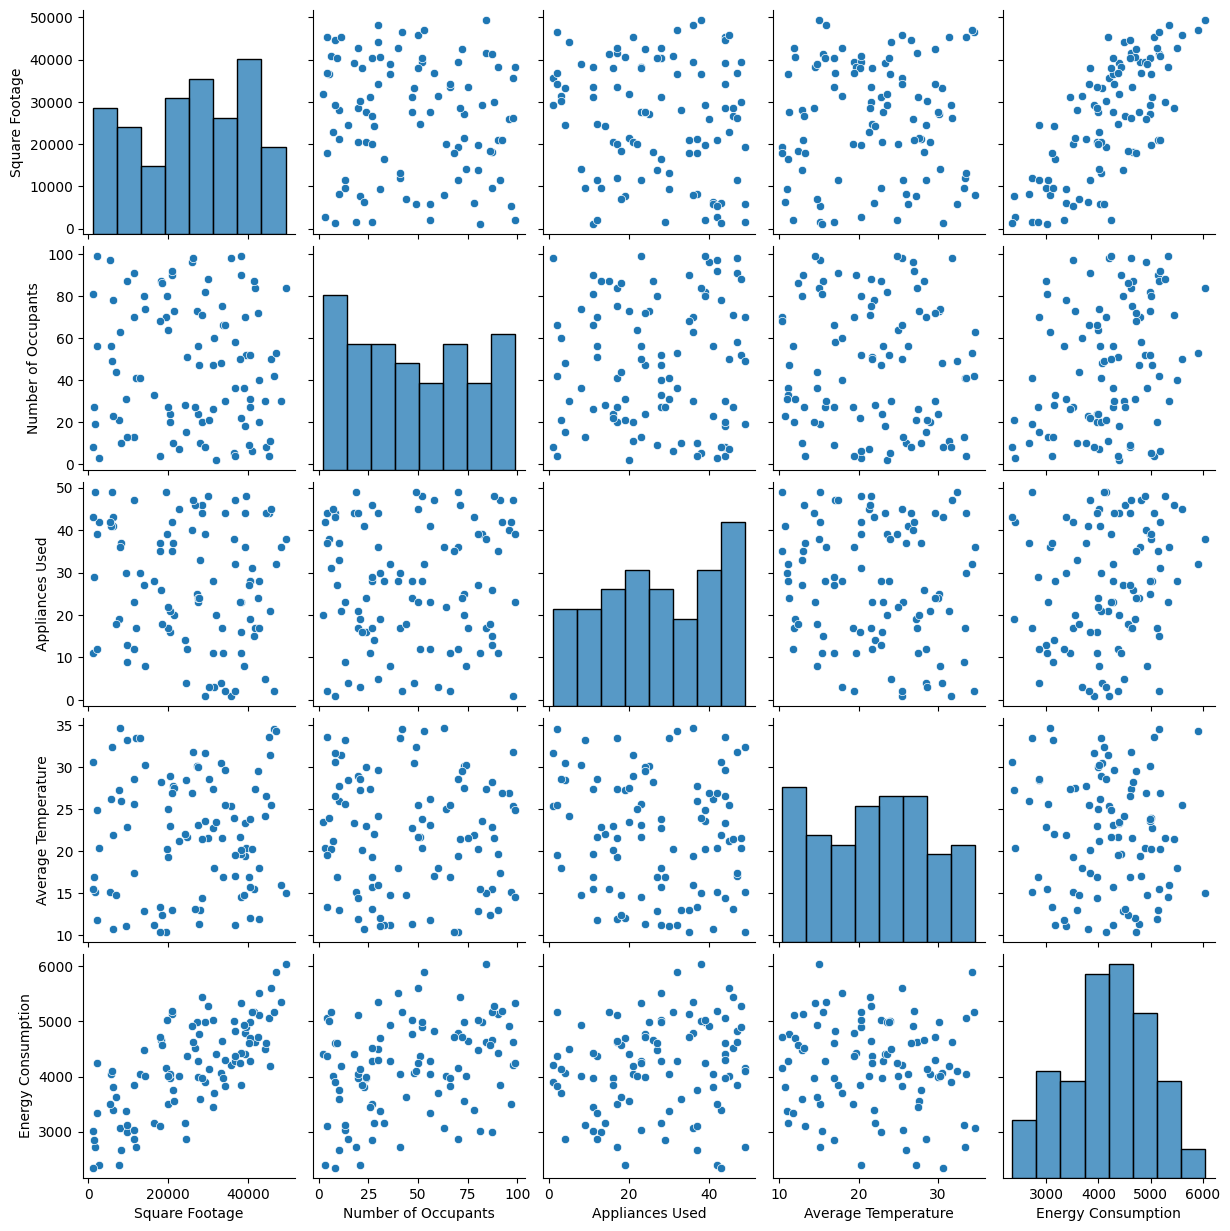

In [46]:
sns.pairplot(
                data = df
)
plt.show()

In [47]:
df['Day of Week'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [48]:
df['Day of Week'] = df['Day of Week'].map({
                            'Weekday' :  1,
                            'Weekend' : 0
})

In [49]:
df['Building Type'].unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [50]:
onc = OneHotEncoder(sparse_output=False)

In [51]:
new_building_dataset = onc.fit_transform(df[['Building Type']])

In [52]:
df = df.drop(columns=['Building Type'])
df = pd.concat([df,pd.DataFrame(new_building_dataset,columns=onc.get_feature_names_out())],axis=1)

In [53]:
df.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential
0,24563,15,4,28.52,1,2865.57,0.0,0.0,1.0
1,27583,56,23,23.07,0,4283.80,1.0,0.0,0.0
2,45313,4,44,33.56,1,5067.83,1.0,0.0,0.0
3,41625,84,17,27.39,0,4624.30,0.0,0.0,1.0
4,36720,58,47,17.08,1,4820.59,0.0,0.0,1.0


In [56]:
X , y = df.drop(columns = ['Energy Consumption']) , df['Energy Consumption']

In [57]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,
                                                            y,
                                                            test_size = 0.3 ,
                                                            random_state = 42
)

In [58]:
scale = StandardScaler()

scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [59]:
from sklearn.ensemble import AdaBoostRegressor

In [60]:
adbr = AdaBoostRegressor(
                            estimator = DecisionTreeRegressor(
                                                                    criterion = 'squared_error',
                                                                    max_depth = 5

                            ),
                            n_estimators = 25,
                            # learning_rate = 0.1,
                            loss = 'linear',
)

In [61]:
adbr.fit(X_train_scalled,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=5)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",25
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provi

In [62]:
adbr.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': 5,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': None,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeRegressor(max_depth=5),
 'learning_rate': 1.0,
 'loss': 'linear',
 'n_estimators': 25,
 'random_state': None}

In [63]:
y_pred_adbr = adbr.predict(X_test_scalled)

In [64]:
residuals_adbr = y_test - y_pred_adbr

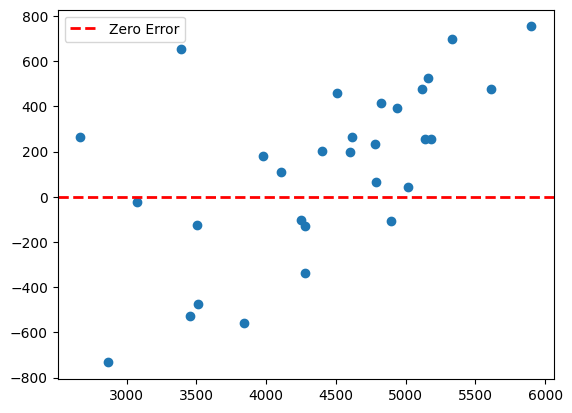

In [65]:
# Residual plot
plt.scatter(y_test,residuals_adbr)
plt.axhline(y = 0, color = 'red', linestyle = '--', lw=2, label='Zero Error')
plt.legend()
plt.show()

In [66]:
r2_score(y_test,y_pred_adbr)

0.758220321061976

In [67]:
root_mean_squared_error(y_test,y_pred_adbr)

397.26948230606337

In [68]:
mean_absolute_error(y_test,y_pred_adbr)

334.8029173687424

In [69]:
cross_val_score(
                    adbr , 
                    X , 
                    y,
                    cv = 7,
                    scoring='r2'
).mean()

np.float64(0.8256247885794539)

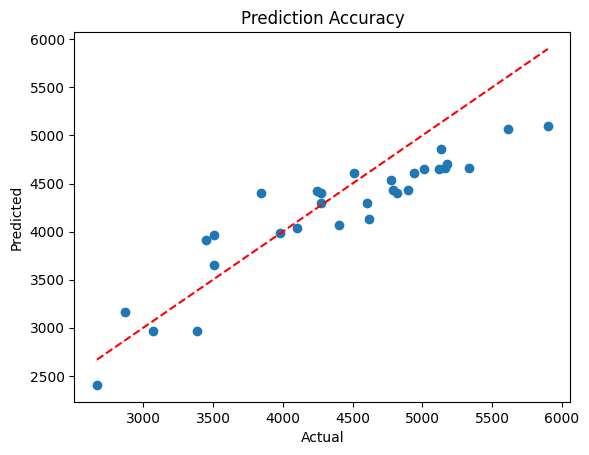

In [34]:
# You are literally plotting Truth vs. Dreams.
# plt.scatter(Actual, Predicted)
plt.scatter(y_test, adbr.predict(X_test_scalled))
# This is the Reference Line of Perfection.
# It represents the equation \(Y=X\) (Predicted = Actual) ; 
'''
                        Why we use it: It gives your eyes a "North Star." 
                        Without this line, you're just looking at a cloud of dots. With this line, you can instantly see:
                        Dots above the line: These are Over-predictions (the model guessed higher than the truth).
                        Dots below the line: These are Under-predictions (the model guessed lower than the truth).
'''
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Prediction Accuracy')
plt.show()


In [70]:
param_grid = {
                    'estimator__max_depth': [5,10],
                    'estimator__min_samples_leaf': [1,2],
                    'estimator': [DecisionTreeRegressor()],  # every value must be in square bracket
                    'learning_rate': [0.1,0.5,1.0],
                    'loss': ['linear','square', 'exponential'],
                    'n_estimators': [10,20,30,50],
}

In [71]:
gcv = GridSearchCV(     
                        estimator = AdaBoostRegressor(estimator=DecisionTreeRegressor()),
                        param_grid = param_grid , 
                        n_jobs = -1,
                        cv = 7,
                        scoring ='r2'
)

In [ ]:
gcv.fit(X_train_scalled,y_train)

In [ ]:
adbr_best = gcv.best_estimator_

In [ ]:
gcv.best_index_

np.int64(67)

In [ ]:
gcv.best_params_

{'estimator': DecisionTreeRegressor(),
 'estimator__max_depth': 5,
 'estimator__min_samples_leaf': 2,
 'learning_rate': 1.0,
 'loss': 'square',
 'n_estimators': 50}

In [ ]:
gcv.best_score_

np.float64(0.8525319792376452)

In [ ]:
adbr_best.fit(X_train_scalled,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...amples_leaf=2)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'square'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provi

In [ ]:
residuals_adbr_best = y_test - adbr.predict(X_test_scalled)

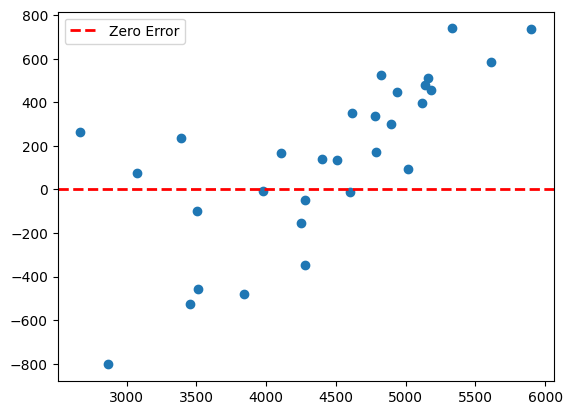

In [ ]:
# Residual plot
plt.scatter(y_test,residuals_adbr_best)
plt.axhline(y = 0, color = 'red', linestyle = '--', lw=2, label='Zero Error')
plt.legend()
plt.show()

In [ ]:
r2_score(y_test,adbr_best.predict(X_test_scalled))

0.7728716588332738

In [ ]:
root_mean_squared_error(y_test,adbr_best.predict(X_test_scalled))

385.04454114036605

In [ ]:
mean_absolute_error(y_test,adbr_best.predict(X_test_scalled))

326.0281481481482

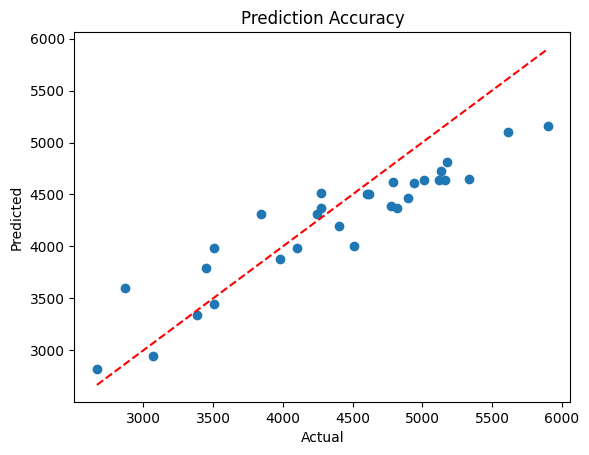

In [ ]:
# You are literally plotting Truth vs. Dreams.
# plt.scatter(Actual, Predicted)
plt.scatter(y_test, adbr_best.predict(X_test_scalled))
# This is the Reference Line of Perfection.
# It represents the equation \(Y=X\) (Predicted = Actual) ; 
'''
                        Why we use it: It gives your eyes a "North Star." 
                        Without this line, you're just looking at a cloud of dots. With this line, you can instantly see:
                        Dots above the line: These are Over-predictions (the model guessed higher than the truth).
                        Dots below the line: These are Under-predictions (the model guessed lower than the truth).
'''
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Prediction Accuracy')
plt.show()


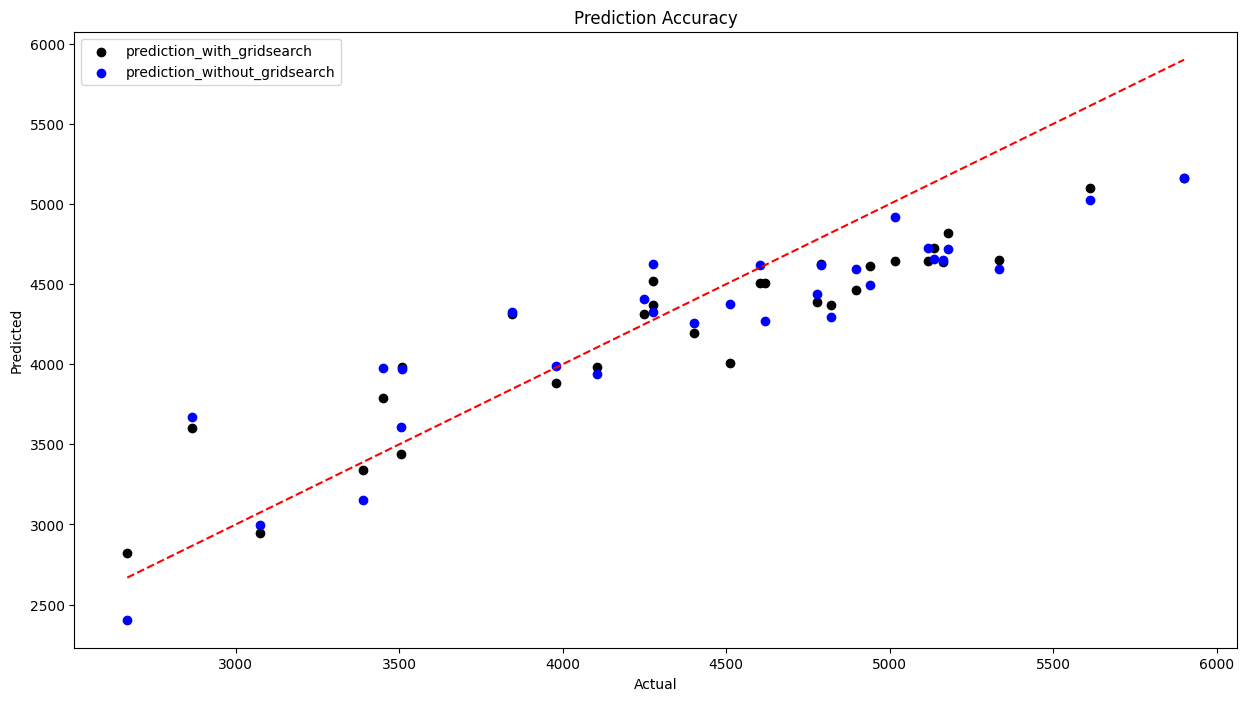

In [ ]:
# Comaprision of predictions
plt.figure(figsize=(15,8))
plt.scatter(y_test, adbr_best.predict(X_test_scalled),color='black',label='prediction_with_gridsearch')
plt.scatter(y_test, adbr.predict(X_test_scalled),color='blue',label='prediction_without_gridsearch')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Prediction Accuracy')
plt.legend()
plt.show()


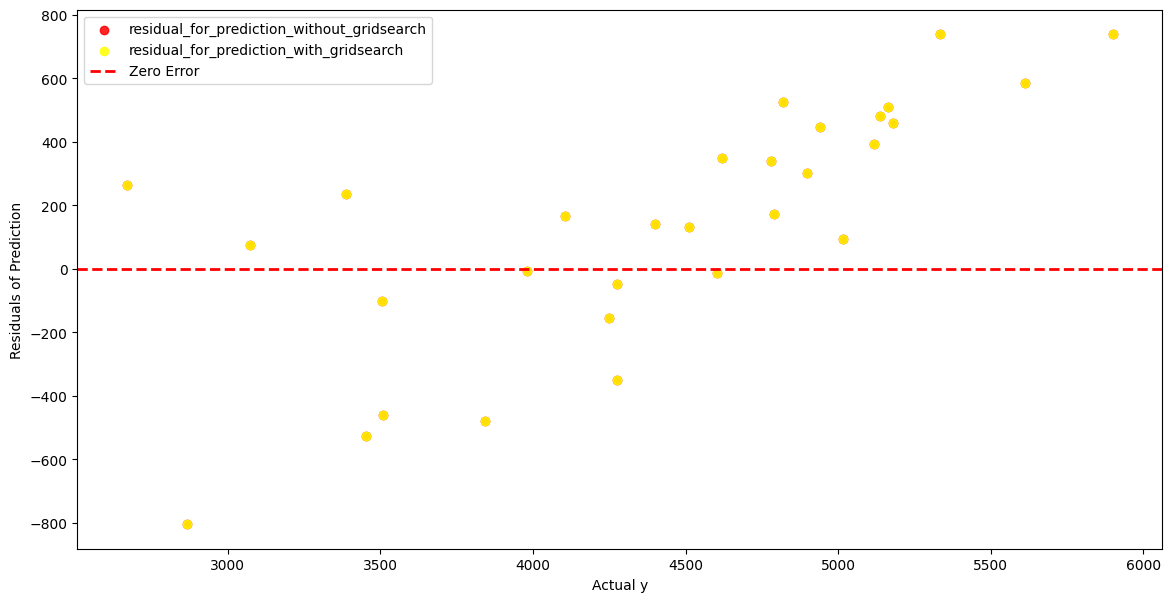

In [ ]:
# Comparision of residuals
plt.figure(figsize=(14,7))
plt.scatter(y_test,residuals_adbr,color = 'red',alpha=0.85,label='residual_for_prediction_without_gridsearch')
plt.scatter(y_test,residuals_adbr_best,color='yellow',alpha=0.85,label='residual_for_prediction_with_gridsearch')
plt.axhline(y = 0, color = 'red', linestyle = '--', lw=2, label='Zero Error')
plt.xlabel('Actual y')
plt.ylabel('Residuals of Prediction')
plt.legend()
plt.show()